# Task 2 - Constraint Satisfaction
### José Antonio Mérida Castejón - 201105

## 0. Modelado

Modelamos la asignación de microservicios como un **CSP** sobre un conjunto de 8 microservicios $\mathcal{M} = \{M_1, M_2, \ldots, M_8\}$ que deben distribuirse entre 3 servidores físicos $\mathcal{S} = \{S_1, S_2, S_3\}$.

A cada microservicio se le asigna un servidor del dominio $\mathcal{D} = \{S_1, S_2, S_3\}$, sujeto a dos tipos de restricciones: una restricción global de capacidad y un conjunto de restricciones binarias de anti-afinidad.

$$\forall (i,j) \in A,\quad X_i \neq X_j \quad \text{y} \quad \forall s \in \mathcal{S},\ |\{i : X_i = s\}| \leq 3$$

Es decir, ningún par de microservicios marcados como anti-afines puede compartir servidor, y ningún servidor puede alojar más de 3 microservicios simultáneamente.

### 0.1 Definición formal del CSP

El CSP se define como la terna $\mathcal{C} = (\mathcal{X}, \mathcal{D}, \mathcal{F})$:

- **Variables:** $\mathcal{X} = \{X_i \mid i \in \{1, \ldots, 8\}\}$, donde $X_i$ es el servidor asignado al microservicio $M_i$.
- **Dominios:** $D_i = \{S_1, S_2, S_3\} \quad \forall i \in \{1, \ldots, 8\}$
- **Factores:** El conjunto $\mathcal{F}$ contiene dos tipos de factores:

  *Factores binarios de anti-afinidad.* Para cada pareja $(i,j) \in A$, donde $A = \{(1,2), (3,4), (5,6), (1,5)\}$:

$$f_{ij}(X_i, X_j) = \begin{cases} 1 & \text{si } X_i \neq X_j \\ 0 & \text{si } X_i = X_j \end{cases}$$

  *Factor global de capacidad.* Sobre el conjunto completo de variables:

$$f_{\text{cap}}(X_1, \ldots, X_8) = \begin{cases} 1 & \text{si } |\{i : X_i = s\}| \leq 3 \ \forall s \in \mathcal{S} \\ 0 & \text{en otro caso} \end{cases}$$

### 0.2 Implementación CSP

Encapsulamos el CSP en una clase `MicroserviceCSP` que mantiene la definición del problema y el estado de la asignación, evitando pasar `X`, `D` y `neighbors` a cada algoritmo.

El constructor inicializa `self.X` con los 8 microservicios en `None`, el dominio compartido `self.D = ['S1', 'S2', 'S3']`, y la lista `self.anti_affinity` con las parejas $(M_1, M_2)$, $(M_3, M_4)$, $(M_5, M_6)$ y $(M_1, M_5)$. A partir de esta última se deriva `self.neighbors`, un diccionario que mapea cada microservicio a sus vecinos anti-afines para consultar restricciones locales eficientemente.

Los factores del modelo formal se implementan como métodos: `f_binary` para anti-afinidad y `f_capacity` para el tope por servidor. `is_consistent` los combina para validar asignaciones parciales durante backtracking, y `is_complete_solution` añade el requisito de que ninguna variable quede en `None`.

In [117]:
# Implementación del CSP, en el proyecto eran únicamente funciones pero creo que
# queda un poco más ordenado dentro de una clase.
class MicroserviceCSP:
    def __init__(self):

        # Capacidad maxima = 3 por servidor
        self.CAPACITY = 3

        # Variables: X = {X_1, ..., X_8}, inicialmente sin asignar
        self.X = {i: None for i in range(1, 9)}

        # Dominio compartido
        self.D = ['S1', 'S2', 'S3']

        # Restricciones binarias de anti-afinidad
        self.anti_affinity = [(1, 2), (3, 4), (5, 6), (1, 5)]

        # Lista de adyacencia con vecinos anti-afines de cada microservicio
        self.neighbors = {i: set() for i in self.X}
        for i, j in self.anti_affinity:
            self.neighbors[i].add(j)
            self.neighbors[j].add(i)

    # Asignar un servidor a un microservicio
    def assign(self, i, server):
        self.X[i] = server

    # Desasignar un servidor a un microservicio
    def unassign(self, i):
        self.X[i] = None

    # Limpiar todas las asignaciones
    def reset(self):
        self.X = {i: None for i in self.X}

    # Retorna todas las variables
    def variables(self):
        return list(self.X.keys())

    # Factor de anti-afinidad
    def f_binary(self, xi, xj):
        return 1 if xi != xj else 0

    # Factor de capacidad
    def f_capacity(self, assignment=None):
        if assignment is None:
            assignment = self.X
        load = {s: 0 for s in self.D}
        for s in assignment.values():
            if s is not None:
                load[s] += 1
                if load[s] > self.CAPACITY:
                    return 0
        return 1

    # Verificación de consistencia, no verifica que se hayan realizado todas las asignaciones
    def is_consistent(self, assignment=None):
        if assignment is None:
            assignment = self.X
        for i, j in self.anti_affinity:
            if self.X[i] is not None and self.X[j] is not None:
                if self.f_binary(self.X[i], self.X[j]) == 0:
                    return False
        return self.f_capacity(self.X) == 1

    # Verificación de consistencia, verifica que la solución esté completa y sea válida
    def is_complete_solution(self, assignment=None):
        if assignment is None:
            assignment = self.X
        return (all(v is not None for v in assignment.values())
                and self.is_consistent(assignment))


# Instancia del CSP
csp = MicroserviceCSP()

## 1. Backtracking Search

El **Backtracking Search** es un algoritmo de búsqueda sistemática para resolver CSPs. Asigna un servidor a cada microservicio de forma secuencial, y si el servidor elegido genera un conflicto retrocede y prueba el siguiente disponible en $D$ hasta encontrar una asignación consistente.

Formalmente, el algoritmo explora un árbol de búsqueda de profundidad $|\mathcal{X}| = 8$ donde cada nivel corresponde a un microservicio y cada rama a un servidor del dominio. Una asignación parcial $\{X_1, \ldots, X_k\}$ es consistente si $\forall (i,j) \in A$ con $i,j \leq k$ se cumple $f_{ij}(X_i, X_j) = 1$, y además $f_{\text{cap}}$ se respeta sobre los microservicios ya asignados.

En la implementación, la función recibe la instancia `csp` y opera recursivamente sobre el índice del microservicio actual, leyendo y mutando directamente `csp.X` mediante `assign` y `unassign`. Para cada servidor del dominio se prueba la asignación y se verifica consistencia con `csp.is_consistent()`, que cubre tanto anti-afinidad como capacidad. Si la rama falla el microservicio se revierte a `None` y se prueba el siguiente servidor. La función retorna `(found, solution)` donde `found` indica si se halló una solución válida y `solution` es una copia (vía `dict(csp.X)`) del estado final.

In [118]:
# Asigna valores del dominio a cada microservicio de manera secuencial
# verificando validez. Si se llega a una asignación inválida, retrocede.
def backtracking(csp, idx=0):

    V = csp.variables()
    D = csp.D

    # Caso base: todos los microservicios están asignados
    if idx == len(V):
        if csp.is_complete_solution():
            return True, dict(csp.X)
        return False, dict(csp.X)

    microservice = V[idx]

    # Probar cada servidor del dominio
    for server in D:
        csp.assign(microservice, server)

        # Verificar consistencia con la asignación parcial actual
        if csp.is_consistent():
            # Continuar con el siguiente microservicio
            ok, result = backtracking(csp, idx + 1)
            if ok:
                return True, result

        # Deshacer la asignación
        csp.unassign(microservice)

    # No hay asignación válida
    return False, dict(csp.X)

### 1.1 Backtracking Search Optimizado (MRV + Forward Checking)

Extendemos el backtracking básico con dos mejoras:

**MRV (Minimum Remaining Values)** reemplaza el orden fijo de microservicios eligiendo en cada paso el que tenga menos servidores disponibles en su dominio activo. Implementa el principio *fail-first*: al atacar primero los más restringidos, las inconsistencias se detectan temprano y se evita comprometer variables en ramas condenadas.

**Forward Checking** elimina proactivamente el servidor recién asignado de los dominios de los vecinos anti-afines sin asignar. Si algún dominio queda vacío, la rama es inviable y se retrocede de inmediato sin profundizar más.

La implementación mantiene un diccionario `domains` con los servidores aún disponibles para cada microservicio, separado del estado `csp.X`. En cada llamada, MRV selecciona el nodo sin asignar con dominio más pequeño y se prueba cada servidor disponible. Si la asignación es consistente, se guarda un `snapshot` de los dominios de los vecinos antes de podarlos; si la recursión falla o algún vecino queda sin opciones  se restauran todos los dominios al estado guardado y se retrocede para probar el siguiente servidor.

In [119]:
# Elige el microservicio más restringido en cada paso (MRV) y poda los dominios
# de los vecinos proactivamente (Forward Checking) para detectar inconsistencias
# antes de seguir profundizando.
def backtracking_optimizado(csp, domains=None):

    # Inicializar dominios en la primera llamada
    if domains is None:
        domains = {i: csp.D[:] for i in csp.variables()}

    V = csp.variables()

    # Caso base: todos los microservicios asignados
    if all(csp.X[i] is not None for i in V):
        return csp.is_complete_solution(), dict(csp.X)

    # MRV: elegir el microservicio sin asignar con menos servidores restantes
    microservice = min(
        (i for i in V if csp.X[i] is None),
        key=lambda i: len(domains[i])
    )

    # Probar cada servidor del dominio restante
    for server in list(domains[microservice]):
        csp.assign(microservice, server)

        # Verificar consistencia
        if csp.is_consistent():

            # Forward Checking: snapshot de dominios y podar vecinos
            snapshot = {j: domains[j][:] for j in csp.neighbors[microservice] if csp.X[j] is None}
            consistent = True

            # Para cada vecino anti-afín
            for j in csp.neighbors[microservice]:
                # Si no se le ha asignado un servidor y el dominio contiene el
                # protocolo del nodo actual
                if csp.X[j] is None and server in domains[j]:
                    domains[j].remove(server)
                    if not domains[j]:
                        consistent = False
                        break

            # Llamada recursiva si la poda no dejó dominios vacíos
            if consistent:
                ok, result = backtracking_optimizado(csp, domains)
                if ok:
                    return True, result

            # Restaurar dominios desde el snapshot
            for j, dom in snapshot.items():
                domains[j] = dom

        # Deshacer la asignación (backtrack)
        csp.unassign(microservice)

    return False, dict(csp.X)

## 2. Beam Search

**Beam Search** mantiene los $K$ mejores estados parciales en cada nivel del árbol de búsqueda. En cada paso expande todos los estados del beam asignando un servidor al siguiente microservicio, evalúa el peso de cada candidato y poda dejando solo los $K$ mejores. A diferencia del backtracking, no es completo ya que con un $K$ pequeño puede descartar todos los caminos que llevan a una solución válida.

Para guiar la poda añadimos un método `violations` a la clase `MicroserviceCSP`. Este recibe una asignación (parcial o completa) y cuenta las restricciones violadas, para cada pareja anti-afín suma 1 si ambos microservicios están en el mismo servidor, y para cada servidor suma el exceso sobre `CAPACITY`. Menor peso es mejor, y un peso de 0 corresponde a una asignación sin violaciones. Lo añadimos al CSP en lugar de definirlo dentro del algoritmo porque la heurística depende directamente de las restricciones del problema, y otros algoritmos (como ICM en el siguiente inciso) también la usarán.

### 2.1 Heurística

In [120]:
# Heurística de cantidad de violaciones
def violations(self, assignment=None):
    if assignment is None:
        assignment = self.X
    count = 0
    # Anti-afinidad
    for i, j in self.anti_affinity:
        if assignment[i] is not None and assignment[j] is not None:
            if assignment[i] == assignment[j]:
                count += 1
    # Capacidad (exceso por servidor)
    load = {s: 0 for s in self.D}
    for s in assignment.values():
        if s is not None:
            load[s] += 1
    for c in load.values():
        if c > self.CAPACITY:
            count += (c - self.CAPACITY)
    return count

MicroserviceCSP.violations = violations

### 2.1 Implementación Beam Search

In [121]:
# Mantiene los K mejores estados parciales en cada nivel del árbol de búsqueda.
# En cada paso expande todos los beams asignando un servidor al siguiente
# microservicio, evalúa el peso de cada candidato (número de restricciones
# violadas) y poda dejando solo los K mejores.
def beam_search(csp, K=3):

    V = csp.variables()

    # Beam inicial: un único estado vacío
    beam = [{i: None for i in V}]

    # Expandir nivel por nivel, un microservicio a la vez
    for microservice in V:
        candidates = []

        # Expandir cada estado del beam actual
        for state in beam:
            for server in csp.D:
                new_state = dict(state)
                new_state[microservice] = server
                candidates.append(new_state)

        # Ordenar por peso y conservar solo los K mejores
        candidates.sort(key=csp.violations)
        beam = candidates[:K]

    # Buscar en el beam final un estado que sea solución válida
    for state in beam:
        if csp.is_complete_solution(state):
            return True, state

    # Si ningún estado del beam final es válido, devolver el mejor (menor peso)
    best = min(beam, key=csp.violations)
    return False, best

## 3. Local Search (ICM)

**Iterated Conditional Modes** parte de una asignación completamente aleatoria y la mejora iterativamente. En cada pasada recorre los microservicios uno por uno y reasigna cada uno al servidor que minimice las violaciones totales, dejando los demás fijos. Termina cuando encuentra una solución válida (peso 0), cuando una pasada completa no produce ninguna mejora (óptimo local), o al alcanza el límite de iteraciones.

A diferencia de backtracking, ICM no es completo ni sistemático ya que puede quedarse atascado en óptimos locales según el punto de partida. También utilizamos un `random.seed` para garantizar que el factor aleatorio sea el mismo durante las diferentes corridas.

In [122]:
import random

random.seed(42)

# Parte de una asignación completamente aleatoria y mejora iterativamente.
# En cada paso elige un microservicio y lo reasigna al servidor que minimice
# el número de restricciones violadas, dejando los demás fijos. Termina cuando
# encuentra una solución válida, cuando ya no puede mejorar (óptimo local), o
# al alcanzar el límite de iteraciones.
def local_search_icm(csp, max_iter=100):

    V = csp.variables()

    # Asignación inicial completamente aleatoria
    for microservice in V:
        csp.assign(microservice, random.choice(csp.D))

    # Bucle principal de mejora
    for it in range(max_iter):

        # Si ya es solución válida, terminar
        if csp.violations() == 0:
            return True, dict(csp.X)

        improved = False

        # Recorrer cada microservicio e intentar mejorar su asignación
        for microservice in V:
            current_server = csp.X[microservice]
            best_server = current_server
            best_weight = csp.violations()

            # Probar cada servidor del dominio
            for server in csp.D:
                if server == current_server:
                    continue
                csp.assign(microservice, server)
                w = csp.violations()
                if w < best_weight:
                    best_weight = w
                    best_server = server

            # Aplicar la mejor reasignación encontrada para este microservicio
            csp.assign(microservice, best_server)
            if best_server != current_server:
                improved = True

        # Optimo local: ninguna reasignación mejoró el peso en toda la pasada
        if not improved:
            return csp.is_complete_solution(), dict(csp.X)

    return csp.is_complete_solution(), dict(csp.X)

## 4. Comparativa

Ejecutamos los cuatro algoritmos sobre la misma instancia del CSP y comparamos su desempeño en tres dimensiones: validez de la solución encontrada, número de restricciones violadas (0 si la solución es factible), y tiempo de ejecución en milisegundos. La medición de tiempo usa `time.perf_counter`, que ofrece la mayor resolución disponible en Python. Dado que el problema tiene un espacio de búsqueda pequeño ($3^8 = 6561$ asignaciones posibles) esperamos que todos encuentren solución rápidamente y que las diferencias de tiempo se midan en fracciones de milisegundo.

### Prompt

I have a MicroserviceCSP class and four solvers (backtracking, backtracking_optimizado, beam_search, local_search_icm), all returning (found, solution). Write a final comparison cell that runs all four on the same instance, times them with perf_counter, prints a table + per-server assignments, and plots a matplotlib bar chart of execution times colored by validity.

### Por que Funciona

Funciona porque el código pegado le da al modelo el contexto exacto (nombres de métodos, firmas, tipos de retorno) sin tener que adivinarlos, evitando que invente interfaces que no existen. Las dos líneas de instrucción son claras y enumeran el entregable concreto sin ambigüedad, y separar instrucciones de código mantiene el prompt corto y legible.

Algoritmo                 Válida   Viol.   Tiempo (ms) 
----------------------------------------------------
Backtracking              Sí       0       0.063       
Backtracking + MRV/FC     Sí       0       0.074       
Beam Search (K=3)         Sí       0       0.091       
Local Search ICM          Sí       0       0.055       

Asignación por servidor:

  Backtracking
    S1: M1, M3, M6
    S2: M2, M4, M5
    S3: M7, M8

  Backtracking + MRV/FC
    S1: M1, M3, M6
    S2: M2, M4, M5
    S3: M7, M8

  Beam Search (K=3)
    S1: M1, M3, M6
    S2: M2, M4, M5
    S3: M7, M8

  Local Search ICM
    S1: M6, M7, M8
    S2: M2, M3, M5
    S3: M1, M4


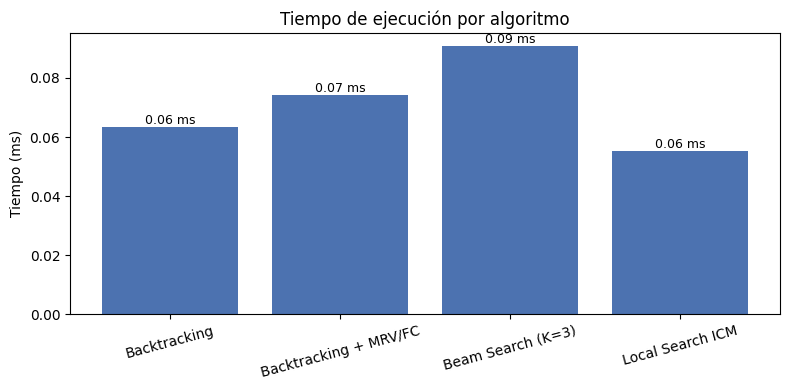

In [123]:
import time
import matplotlib.pyplot as plt

# Ejecutar cada algoritmo y medir tiempo
csp.reset()
start = time.perf_counter()
found1, sol1 = backtracking(csp)
t1 = (time.perf_counter() - start) * 1000

csp.reset()
start = time.perf_counter()
found2, sol2 = backtracking_optimizado(csp)
t2 = (time.perf_counter() - start) * 1000

start = time.perf_counter()
found3, sol3 = beam_search(csp, K=3)
t3 = (time.perf_counter() - start) * 1000

csp.reset()
start = time.perf_counter()
found4, sol4 = local_search_icm(csp, max_iter=100)
t4 = (time.perf_counter() - start) * 1000

results = [
    ("Backtracking",          found1, sol1, t1),
    ("Backtracking + MRV/FC", found2, sol2, t2),
    ("Beam Search (K=3)",     found3, sol3, t3),
    ("Local Search ICM",      found4, sol4, t4),
]

# Tabla de resultados
print(f"{'Algoritmo':<25} {'Válida':<8} {'Viol.':<7} {'Tiempo (ms)':<12}")
print("-" * 52)
for name, found, sol, t in results:
    print(f"{name:<25} {'Sí' if found else 'No':<8} {csp.violations(sol):<7} {t:<12.3f}")

# Asignaciones agrupadas por servidor
print()
print("Asignación por servidor:")
for name, _, sol, _ in results:
    groups = {s: sorted(f"M{m}" for m, srv in sol.items() if srv == s) for s in csp.D}
    print(f"\n  {name}")
    for s in csp.D:
        print(f"    {s}: {', '.join(groups[s]) or '-'}")

# Gráfica comparativa de tiempos
fig, ax = plt.subplots(figsize=(8, 4))
names = [r[0] for r in results]
times = [r[3] for r in results]
colors = ['#4c72b0' if r[1] else '#c44e52' for r in results]

bars = ax.bar(names, times, color=colors)
ax.set_ylabel("Tiempo (ms)")
ax.set_title("Tiempo de ejecución por algoritmo")
ax.tick_params(axis='x', rotation=15)

# Etiquetar cada barra con su valor
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{t:.2f} ms", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Respuestas a Preguntas:

### 1. Validez de Soluciones
Todos los algoritmos encontraron soluciones válidas, verificadas por medio de la función de verificación al igual que verificación manual. Esto realmente es de esperarse, es un espacio de búsqueda pequeño con pocas restricciones. Por ejemplo, la restricción de tamaño únicamente nos dice que los servidores se deben encontrar en una configuración (3,3,2) lo cuál es bastante parejo. Al momento que tuviéramos por ejemplo menos servidores, o un split menos parejo (por ejemplo, un servidor debe de tener 4) el espacio de soluciones se volvería más pequeño. Además, dados los pares de microservicios afines se puede llegar a una solución por inspección de manera relativamente fácil. Los primeros 3 pares se asignan a los servidores 1 y 2 manteniéndolos separados, luego para el último microservicio con afinidad (M5) se le asigna el tercer servidor. Los demás quedan completamente libres. Por último, valdría la pena explorar como afecta el orden de exploración. En este caso, exploramos los microservicios más restringidos primero y es más posible que fallemos temprano. Esto puede explicar por qué el backtracking tradicional comprobó ser eficiente en la resolución del problema planteado.

### 2. Medición de Tiempo

Realizado en la celda anterior.

### 3. Comparación de Tiempos

Los cuatro algoritmos resolvieron el problema en menos de 0.1 ms, con diferencias de microsegundos que en una instancia tan pequeña no son particularmente significativas. ICM resultó el más rápido (0.055 ms), seguido del Backtracking básico (0.063 ms), su versión optimizada con MRV + FC (0.074 ms) y Beam Search (0.091 ms). Es interesante notar que el Backtracking optimizado fue *más lento* que el básico. Las heurísticas como mantener dominios activos, calcular MRV en cada paso y hacer snapshots para Forward Checking agregan overhead que puede ser perjudicial para problemas con un espacio de soluciones amplio como este. Si el Backtracking básico no necesita retroceder, las heurísticas adicionales únicamente agregan costo computacional.

Beam Search paga un costo fijo por nivel. En cada uno de los 8 microservicios expande $K \times |D| = 9$ candidatos, los ordena por número de violaciones y poda los $K$ peores. Aunque cada paso individual es barato, este overhead constante no compite con la simplicidad del backtracking directo en un problema donde basta una sola pasada secuencial para llegar a la solución. Además, Beam Search es el único algoritmo sistemático que no garantiza completitud, con un $K$ pequeño podría descartar el camino que lleva a una solución válida, aunque en este caso $K=3$ resultó suficiente y hasta se podría considerar un $k = 1$ para una búsqueda Greedy. ICM, por su parte, fue el más rápido a pesar de operar sobre asignaciones completas en lugar de parciales. Esto se debe a que el problema cuenta con un espacio de soluciones suficientemente amplio como para que la inicialización aleatoria caiga cerca de un óptimo, y unas pocas pasadas de mejora local bastan para alcanzarlo. Sin embargo, este resultado depende fuertemente de la inicialización aleatoria, con otra inicialización ICM podría quedarse atascado en un óptimo local subóptimo y reportar una solución inválida.